# Control Flow And Conditionals

This notebook is the sixth step in the operator sequence. The focus here is on the operators that make decomposition pipelines behave more like small programs: branching, repeated application, and predicate-controlled iteration.

Previous: [05 Binary And Combination Operators](./example_abstract_graph_operators_05_binary_and_combination_operators.ipynb)  
Next: [07 XML And Operator Serialization](./example_abstract_graph_operators_07_xml_and_operator_serialization.ipynb)


Previous: [09 Feature Inspection And Subgraphs](./example_abstract_graph_operators_09_feature_inspection_and_subgraphs.ipynb)

This notebook uses the same toy graph as the earlier staged examples, but the emphasis is different: the interesting part is no longer the decomposition primitive itself, but the logic that decides when and how often to apply it.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import networkx as nx
import pandas as pd
from toolz import curry
from IPython.core.display import HTML
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
HTML('<style>.container { width:95% !important; }</style>')


In [3]:
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.display import display, display_decomposition_graph, display_graph, display_mappings, decomposition_to_graph
from abstractgraph.operators import *


def draw(graph, decomposition_function, *, nbits=8, size=(12, 6), n_elements_per_row=8):
    display_decomposition_graph(decomposition_function)
    ag = graph_to_abstract_graph(graph, decomposition_function=decomposition_function, nbits=nbits)
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


## The same toy graph

We keep the graph fixed so the changes in output are attributable to control flow, not to new structure in the input.


Graph with 8 nodes and 9 edges


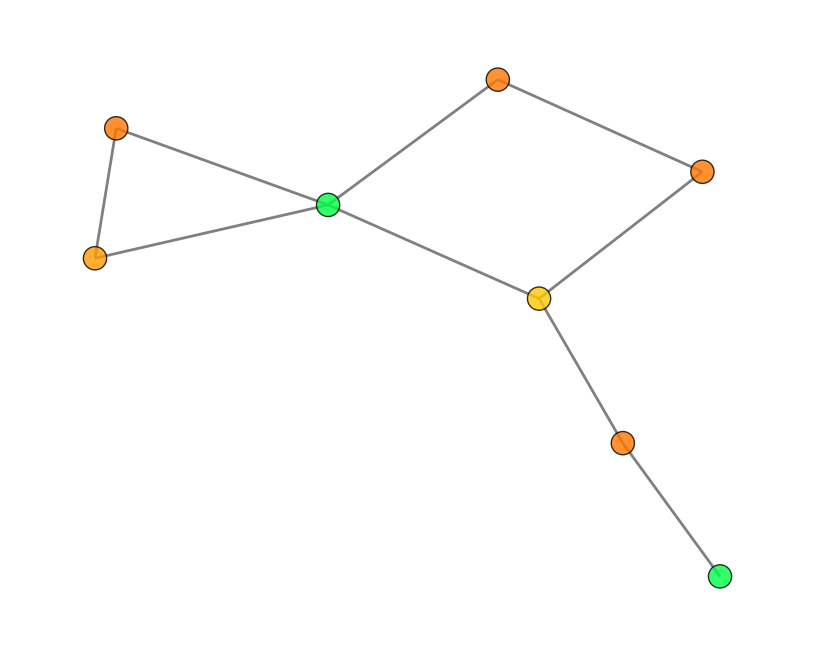

In [4]:
graph = nx.Graph()
graph.add_nodes_from([
    (0, {'label': 'C'}),
    (1, {'label': 'C'}),
    (2, {'label': 'O'}),
    (3, {'label': 'N'}),
    (4, {'label': 'C'}),
    (5, {'label': 'S'}),
    (6, {'label': 'C'}),
    (7, {'label': 'O'}),
])
graph.add_edges_from([
    (0, 1, {'label': 'ring'}),
    (1, 2, {'label': 'ring'}),
    (2, 3, {'label': 'ring'}),
    (3, 0, {'label': 'ring'}),
    (2, 4, {'label': 'bridge'}),
    (4, 5, {'label': 'ring'}),
    (5, 2, {'label': 'ring'}),
    (3, 6, {'label': 'branch'}),
    (6, 7, {'label': 'branch'}),
])

print(graph)
display_graph(graph)


## Small predicates over `AbstractGraph` state

The control-flow operators need predicates. The original overview notebook defined small local predicates with `@curry`; we keep the same pattern here so thresholds can be configured cleanly.


In [5]:
@curry
def number_of_image_graph_nodes_greater_then(abstract_graph, threshold=1):
    return number_of_image_graph_nodes(abstract_graph) > threshold


@curry
def number_of_image_graph_nodes_less_then(abstract_graph, threshold=1):
    return number_of_image_graph_nodes(abstract_graph) < threshold


@curry
def number_of_subgraph_nodes_greater_then(abstract_graph, threshold=1):
    return max_number_of_subgraph_nodes(abstract_graph) >= threshold


## `if_then_else(...)`

Start with a pipeline that produces several interpretation nodes. Then branch: if there are more than two interpretation nodes, merge them; otherwise leave the graph unchanged.


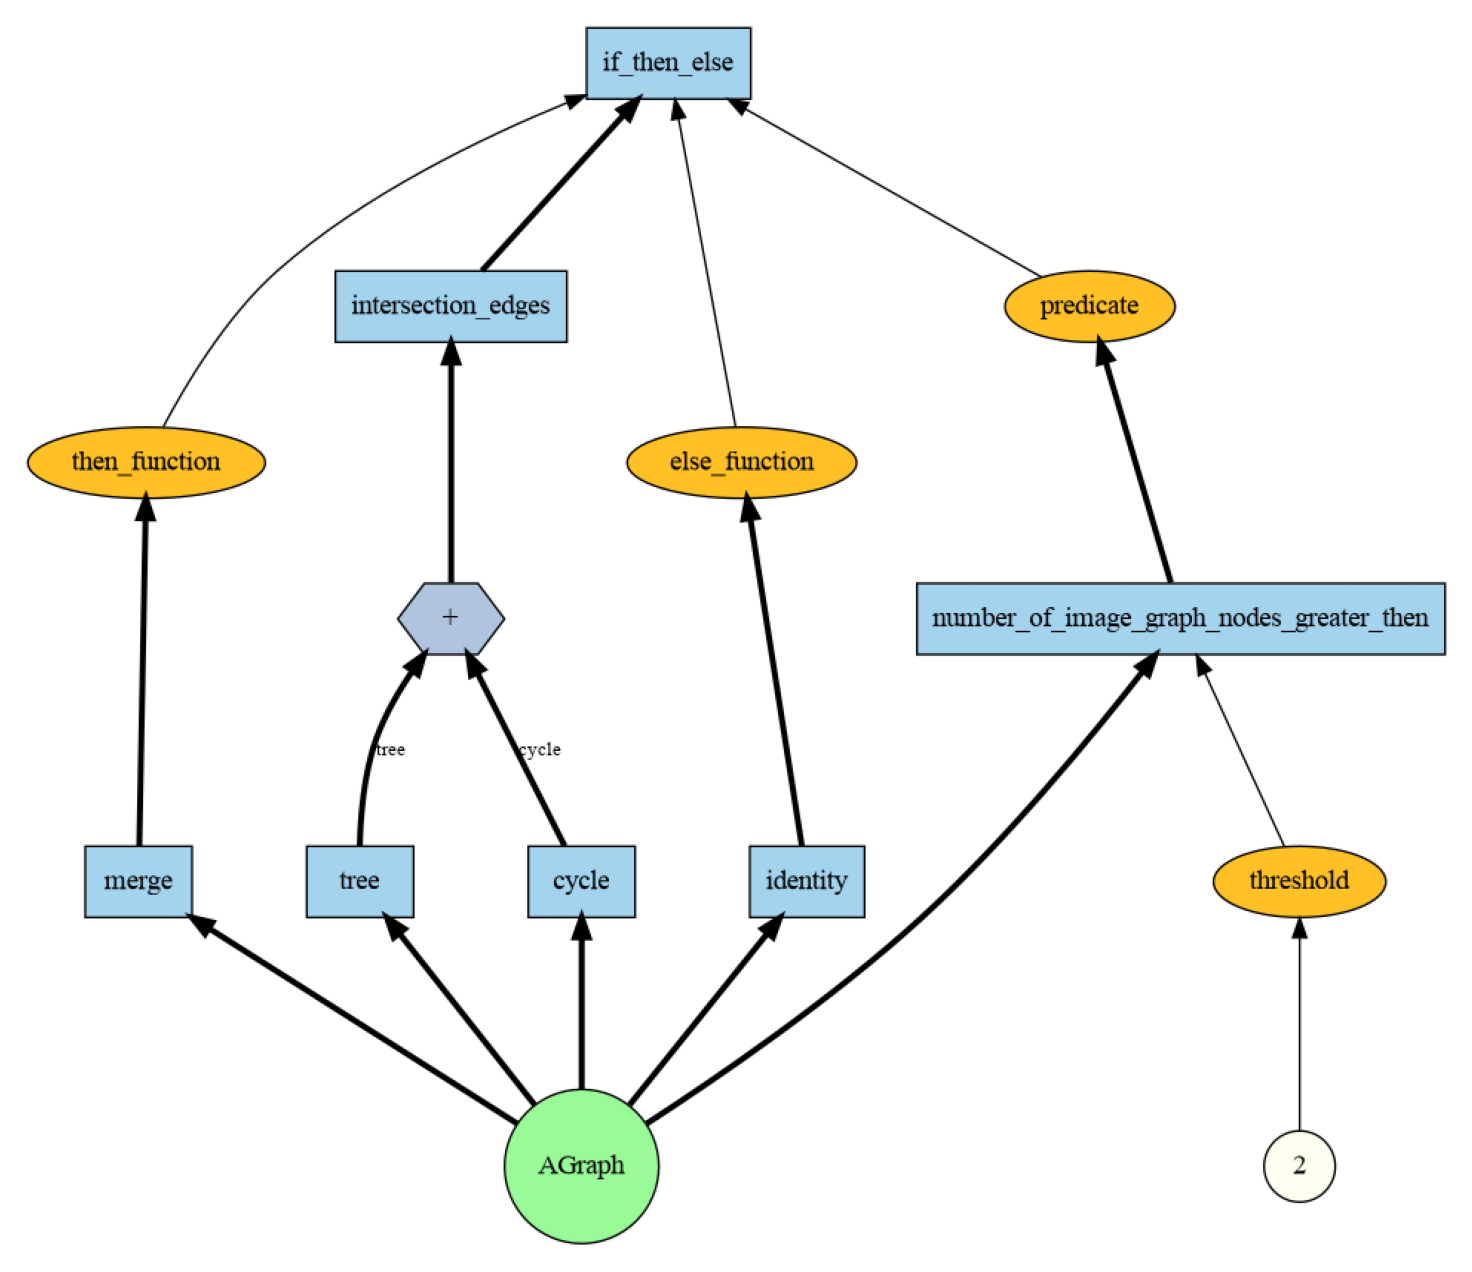

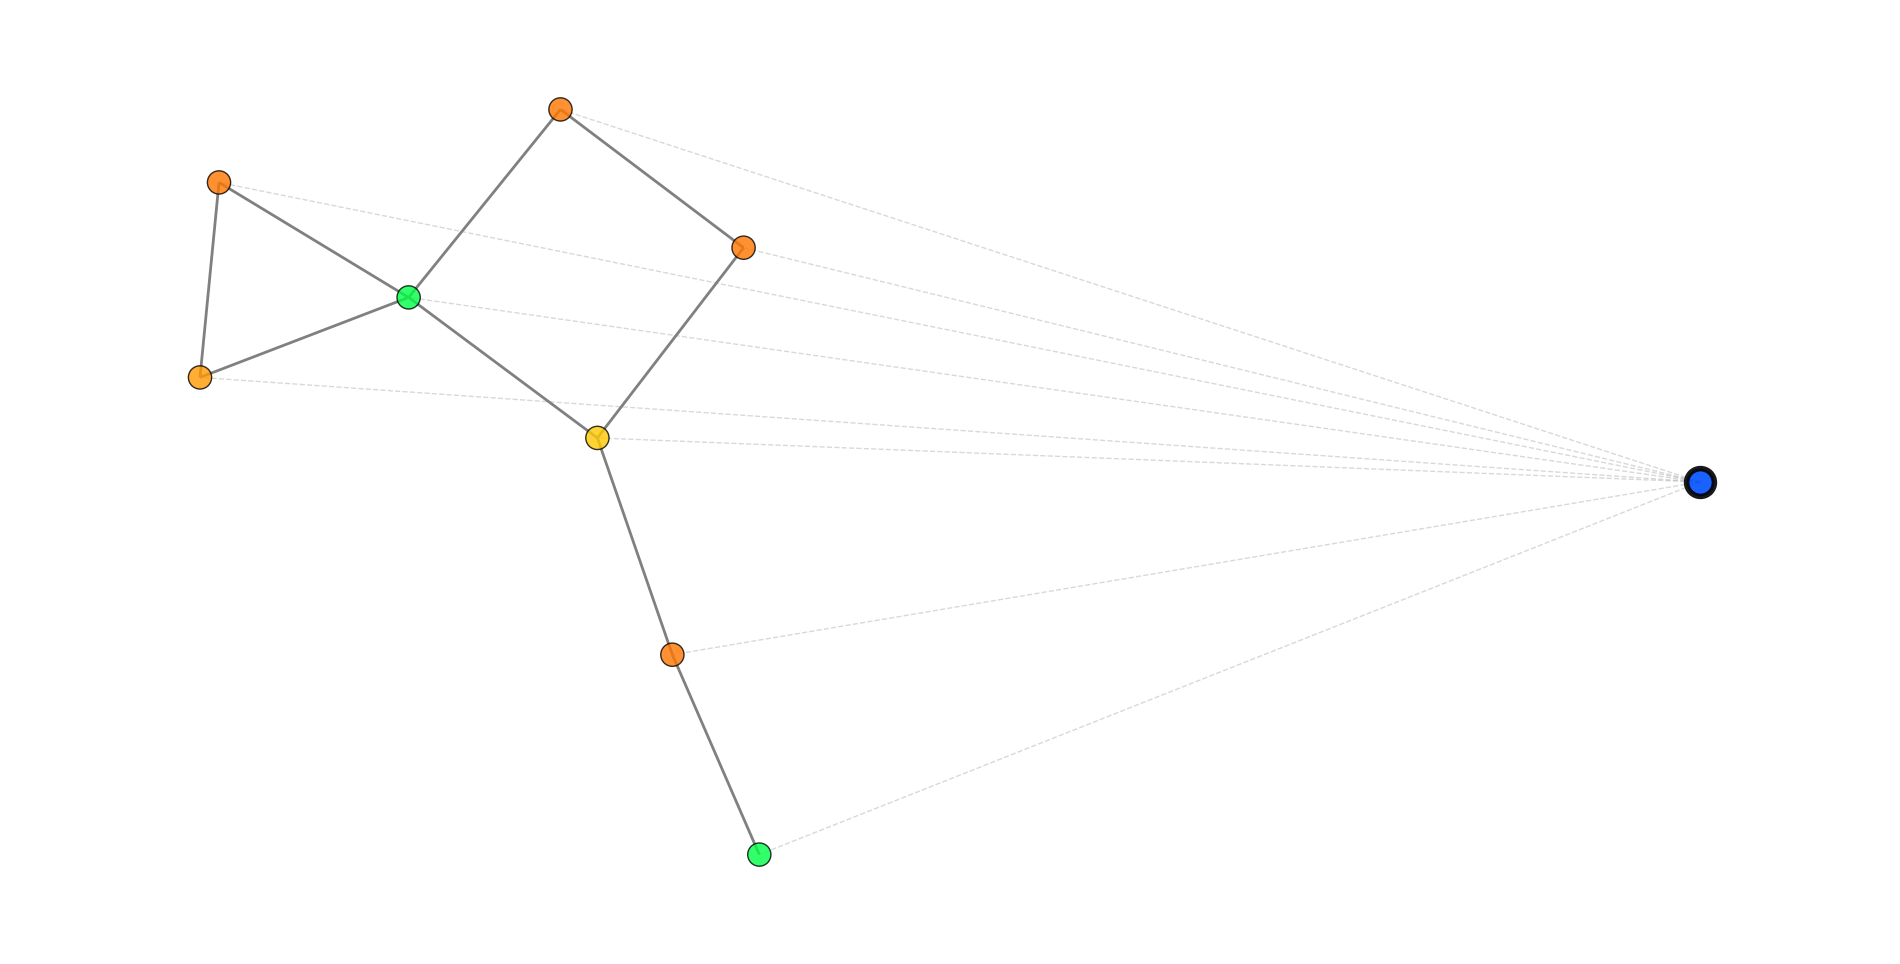

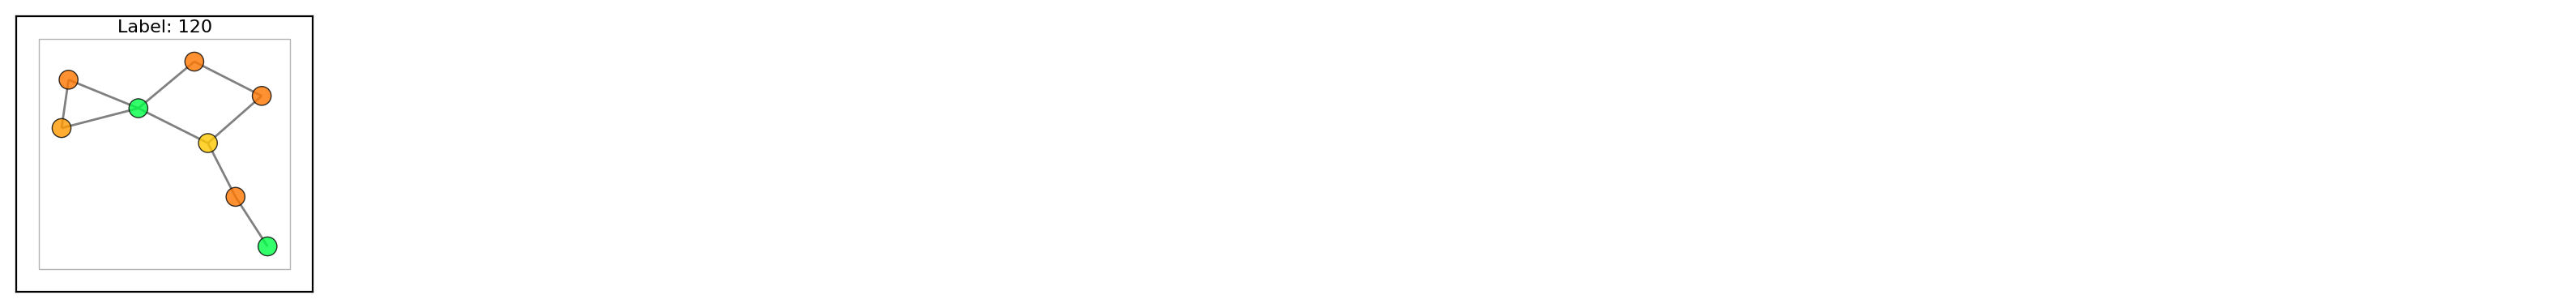

In [6]:
step1 = compose(intersection_edges(), add(cycle(), tree()))
workflow = compose(
    if_then_else(
        predicate=number_of_image_graph_nodes_greater_then(threshold=2),
        then_function=merge(),
        else_function=identity(),
    ),
    step1,
)
if_then_else_ag = draw(graph, workflow)


## `if_then_elif_else(...)`

This operator extends the same idea to multiple ordered branches. The first predicate that matches wins.


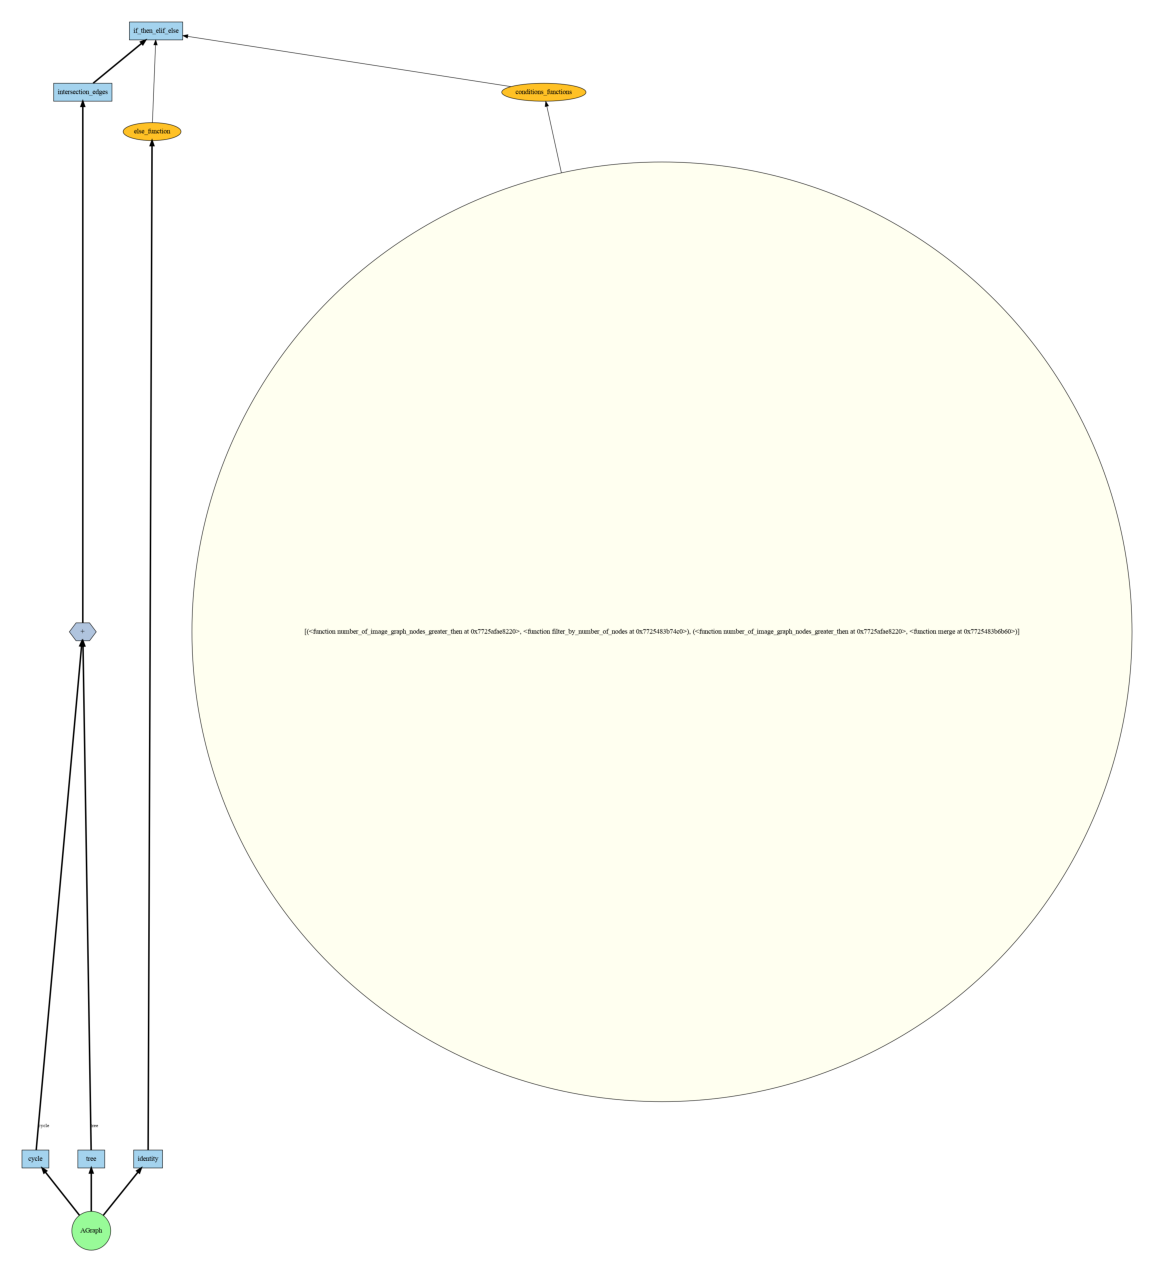

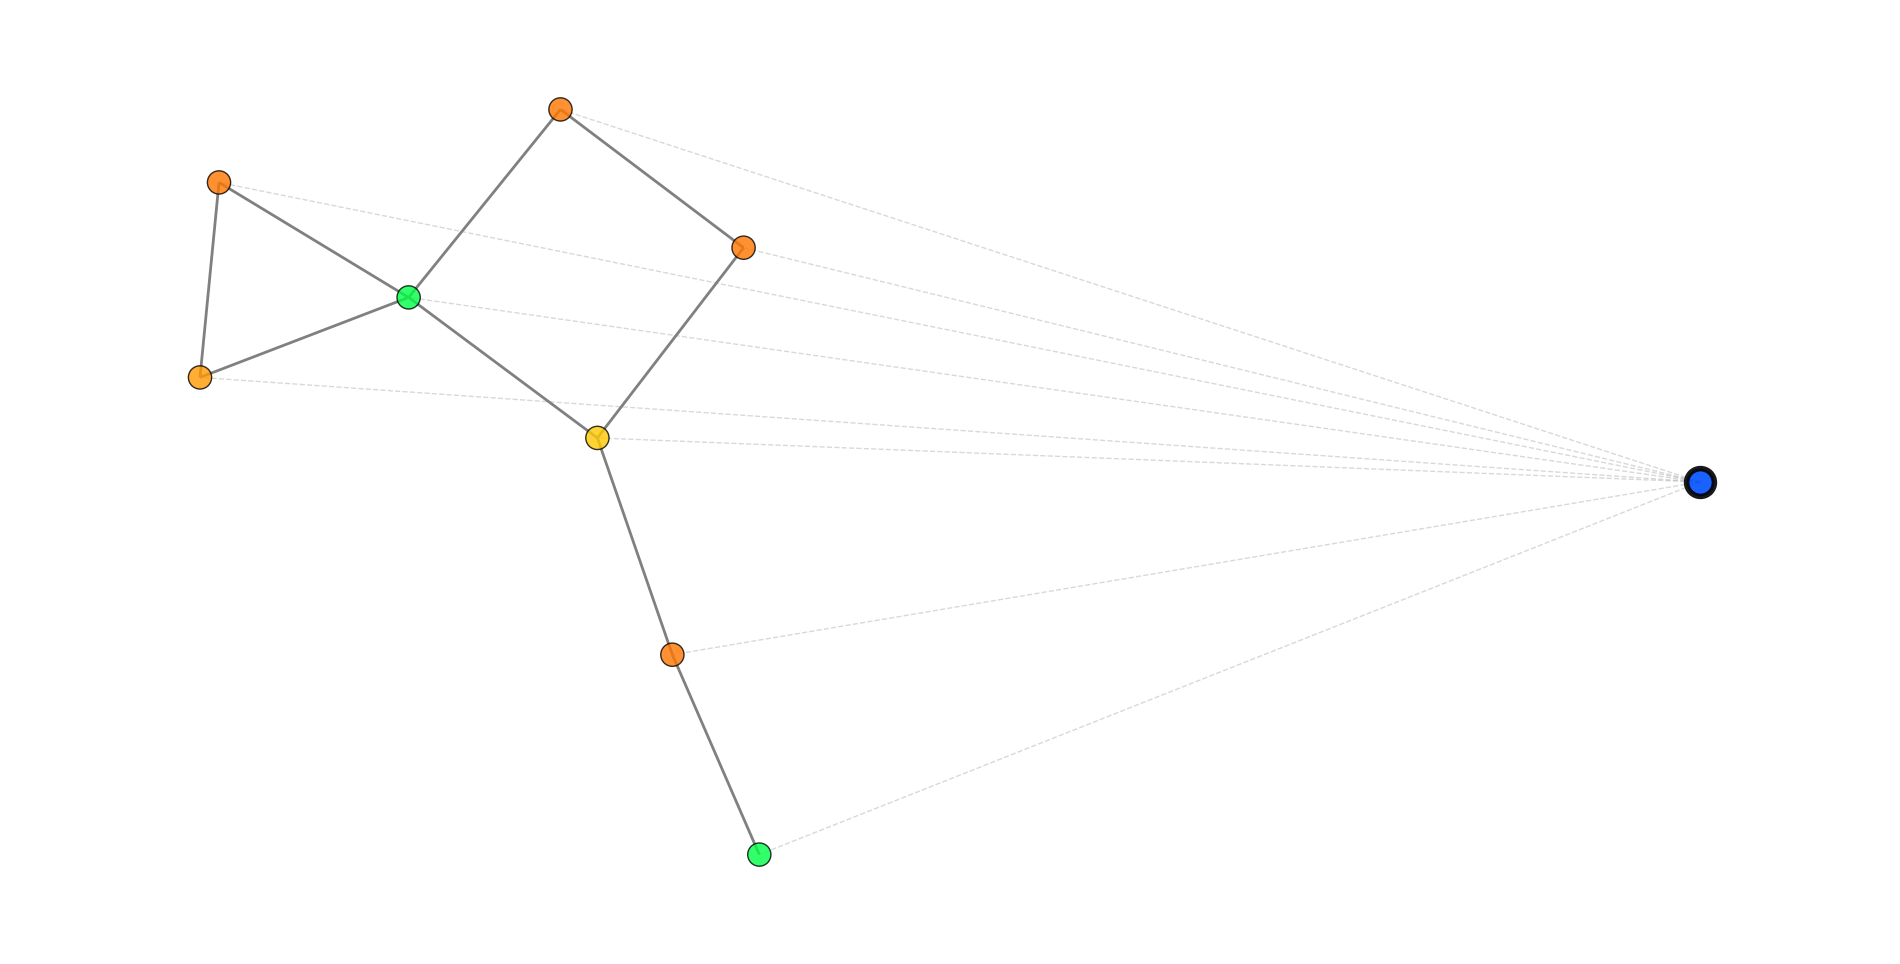

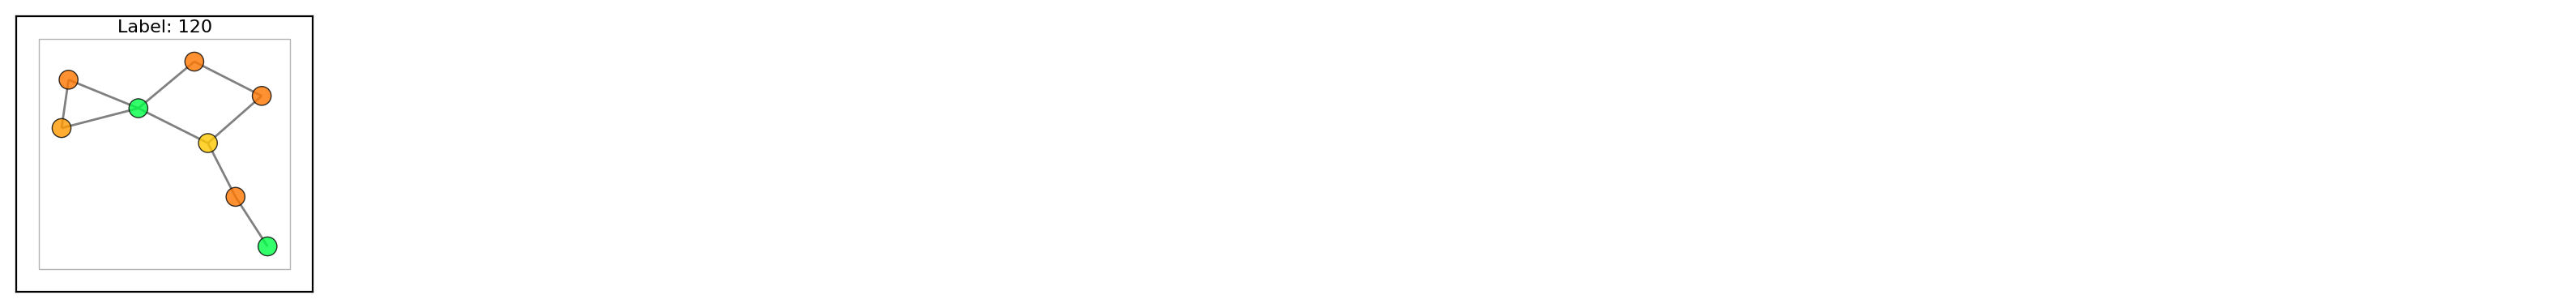

In [7]:
workflow = compose(
    if_then_elif_else(
        conditions_functions=[
            (number_of_image_graph_nodes_greater_then(threshold=10), filter_by_number_of_nodes(number_of_nodes=(1, 3))),
            (number_of_image_graph_nodes_greater_then(threshold=2), merge()),
        ],
        else_function=identity(),
    ),
    step1,
)
if_then_elif_else_ag = draw(graph, workflow)


In this example, the second branch fires because the first threshold is too high and the graph still has more than two interpretation nodes after `step1`.


## `for_loop(...)`

A fixed-count loop is useful when you want bounded iterative expansion. Here we apply a neighborhood decomposition twice and then deduplicate overlapping outputs.


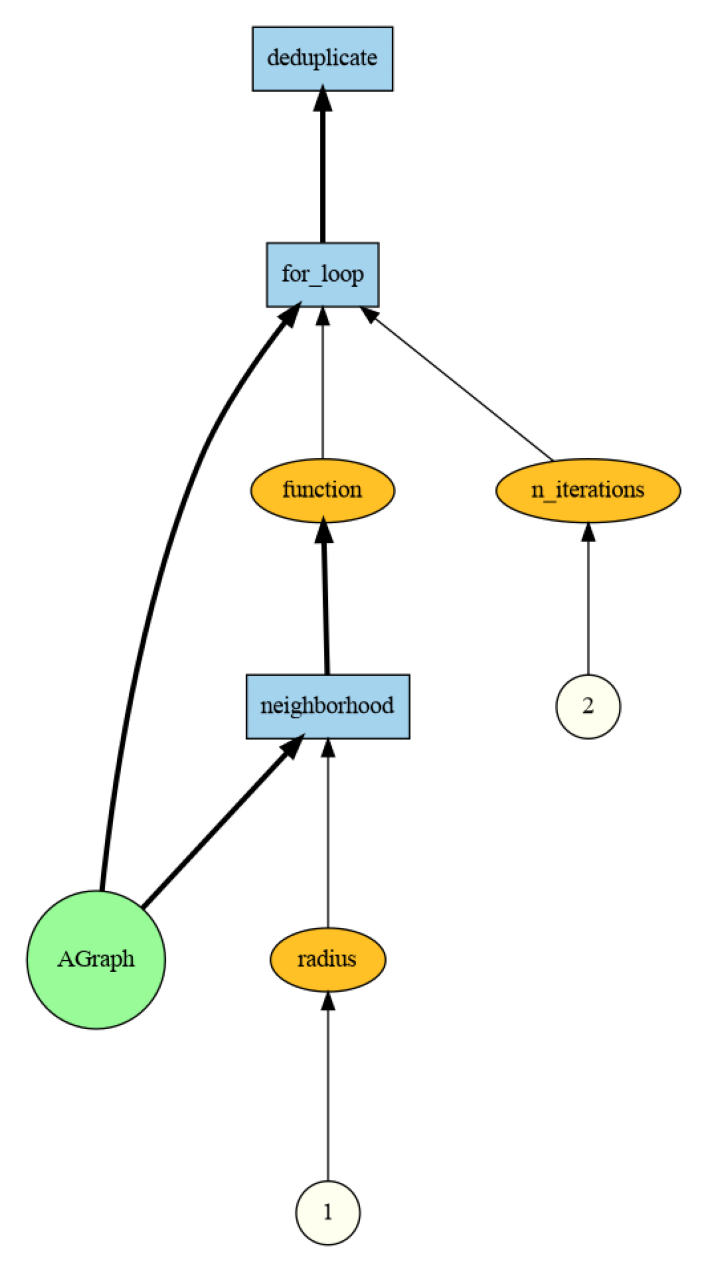

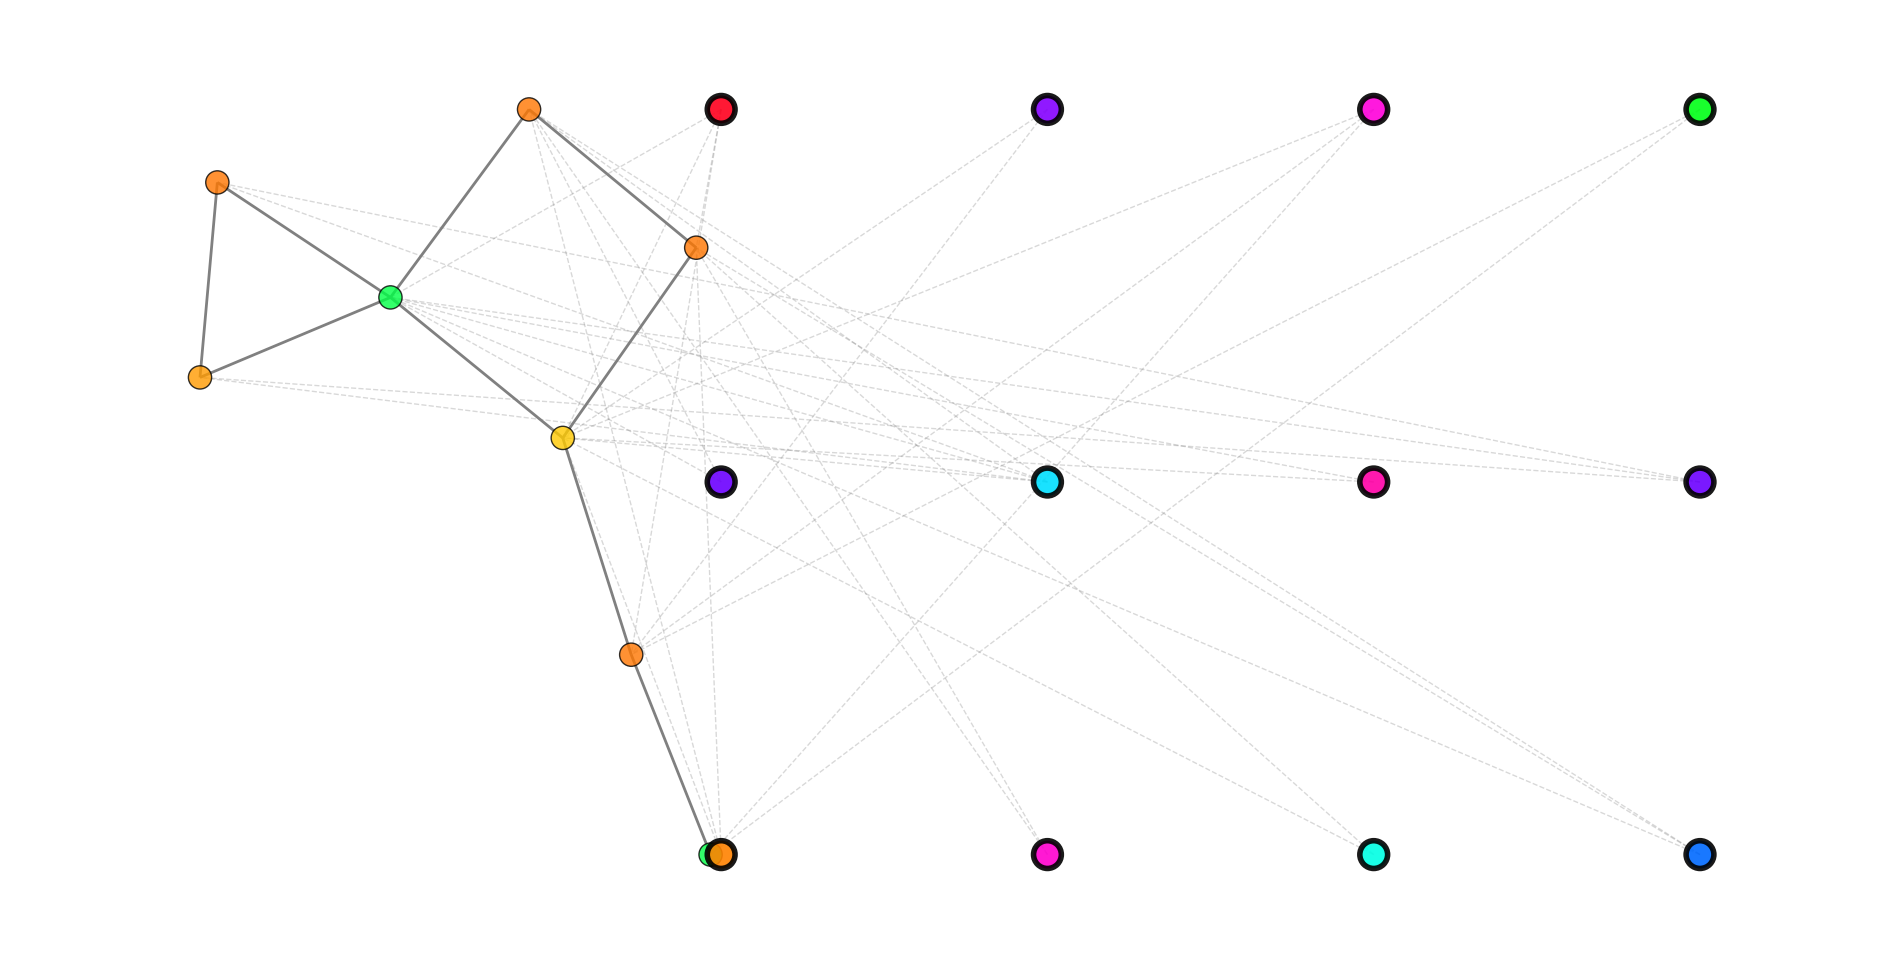

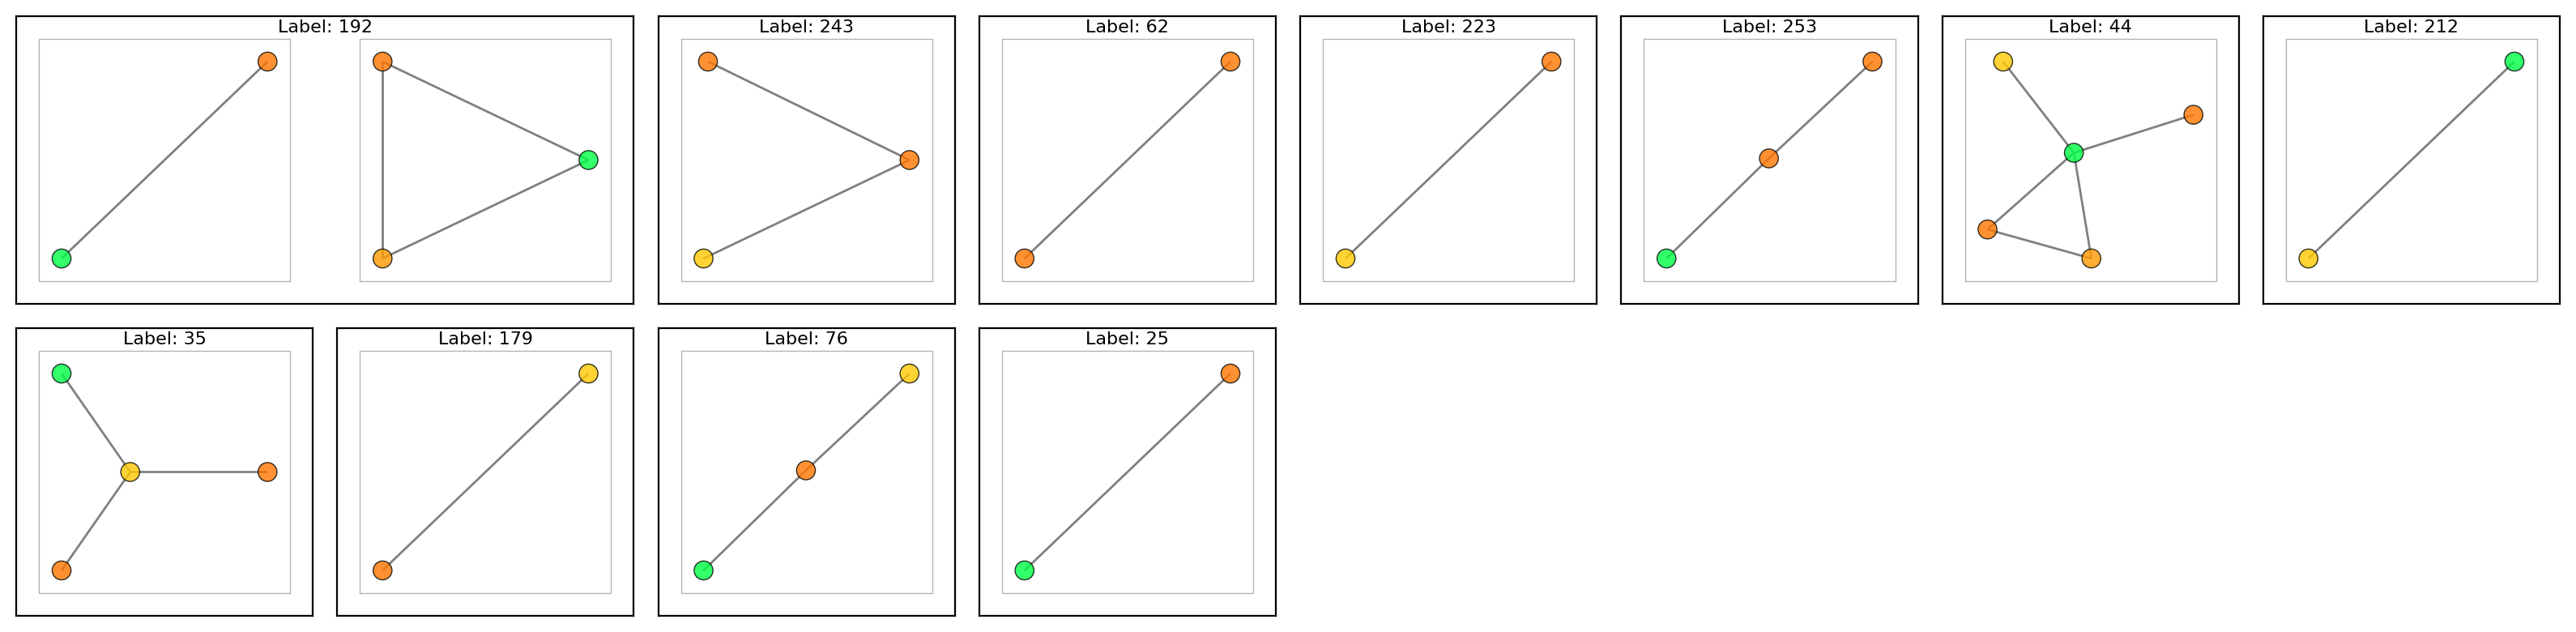

In [8]:
loop_df = compose(deduplicate(), for_loop(function=neighborhood(radius=1), n_iterations=2))
for_loop_ag = draw(graph, loop_df)


## `while_loop(...)` with a subgraph-size predicate

`while_loop(...)` keeps applying a function until a predicate becomes false or the iteration cap is hit. This example starts from the connected component and keeps splitting while any mapped subgraph has at least five nodes.


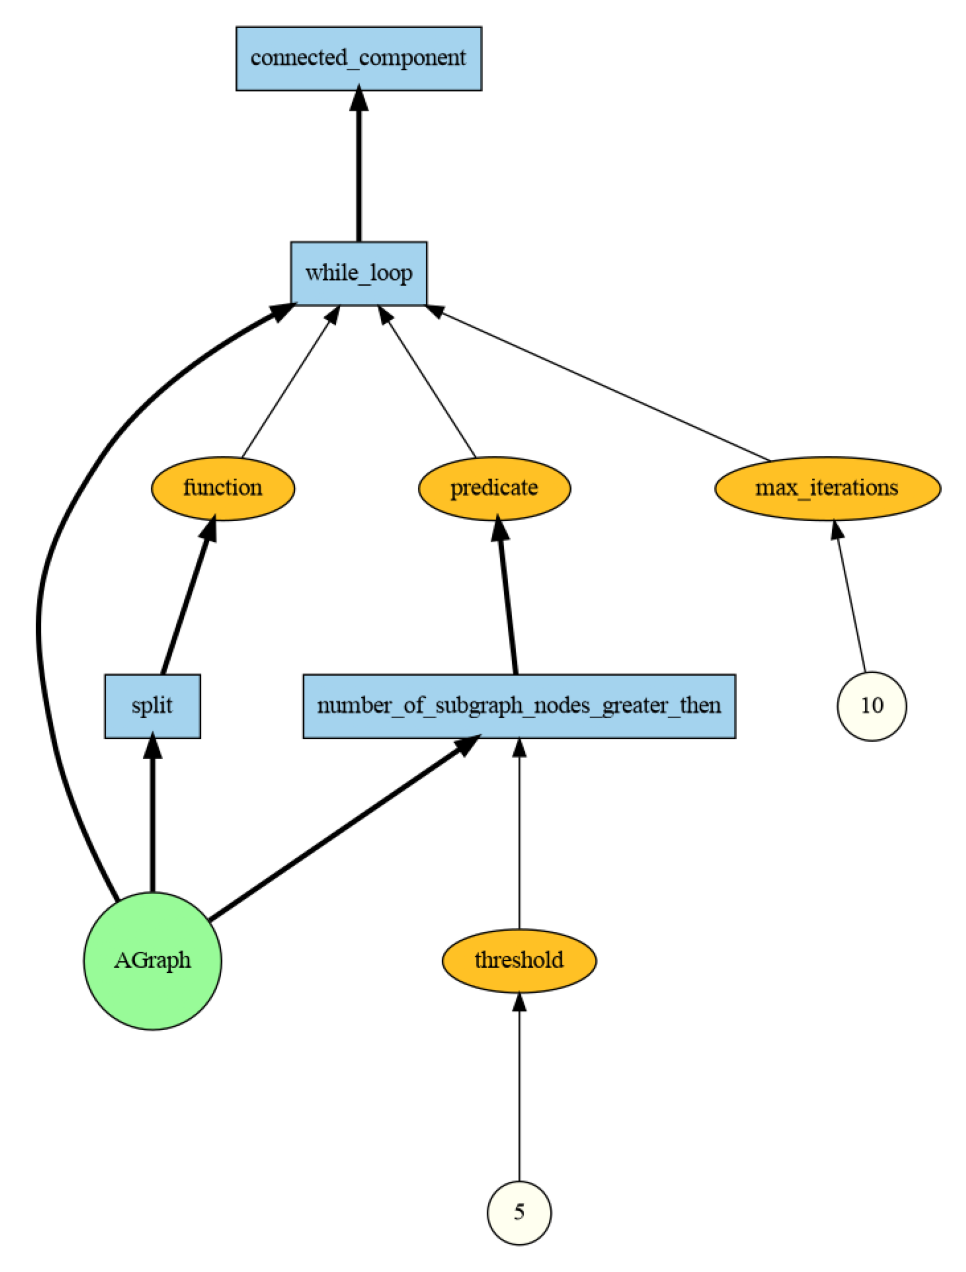

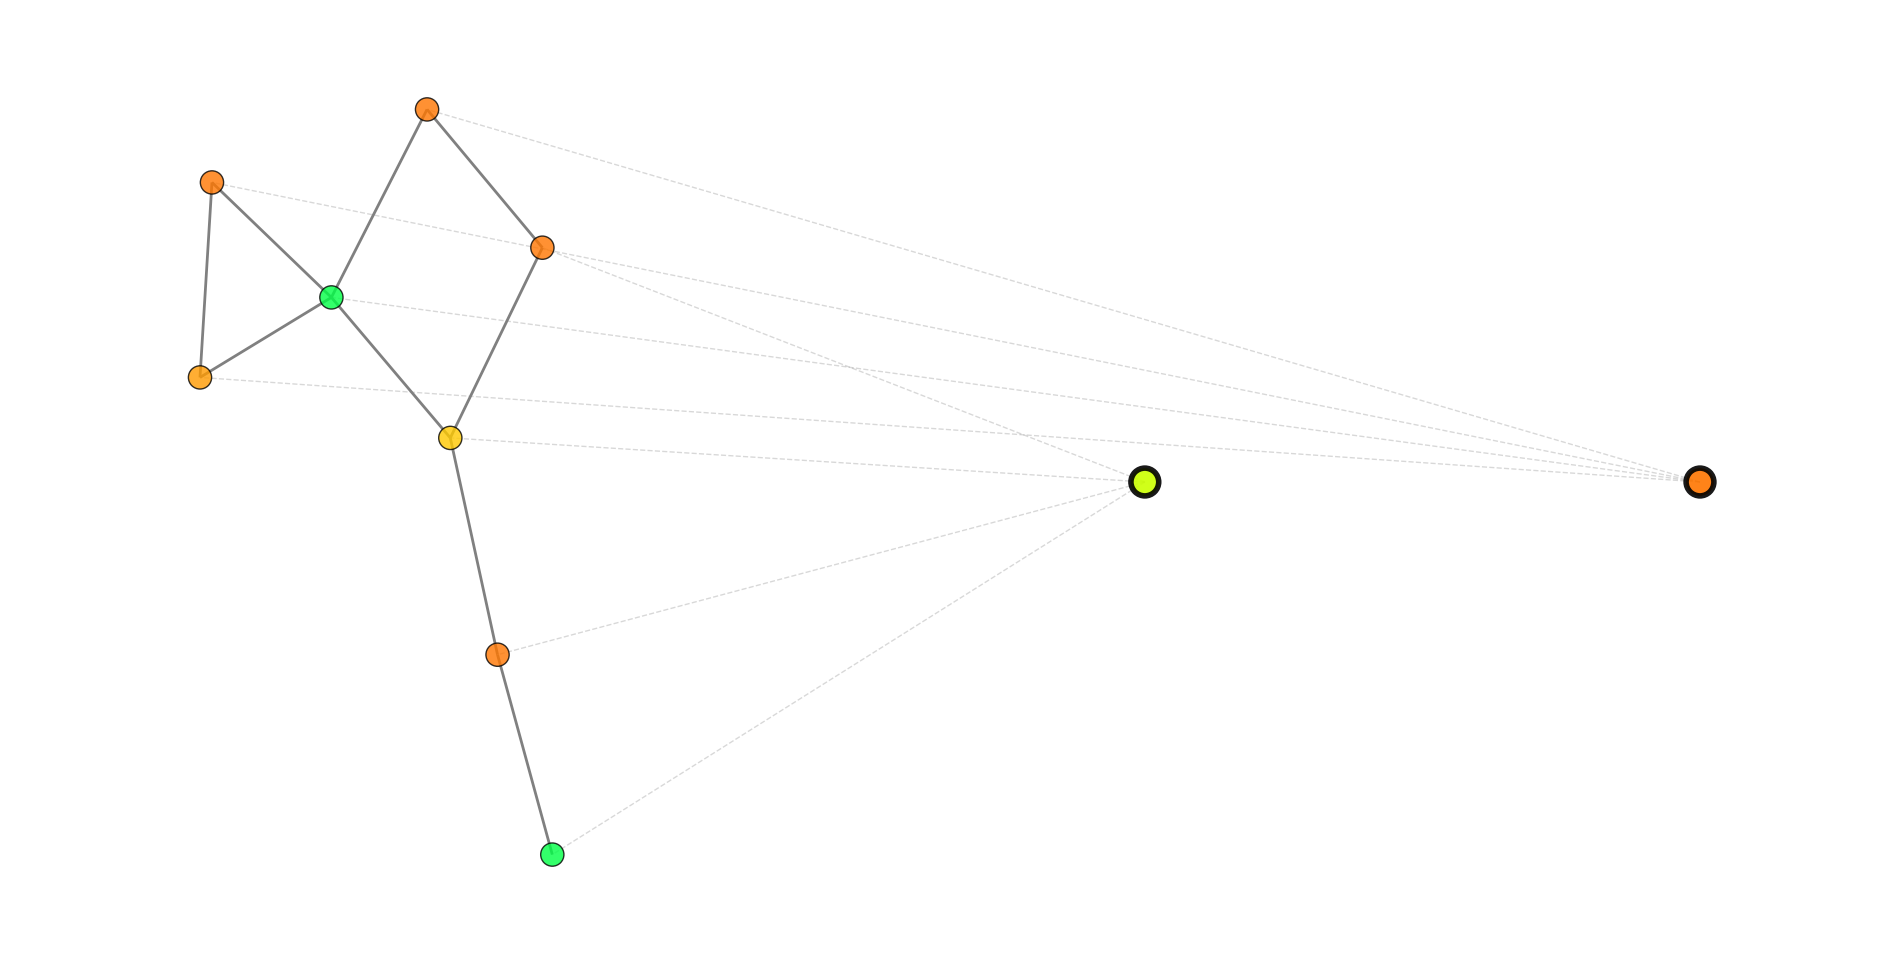

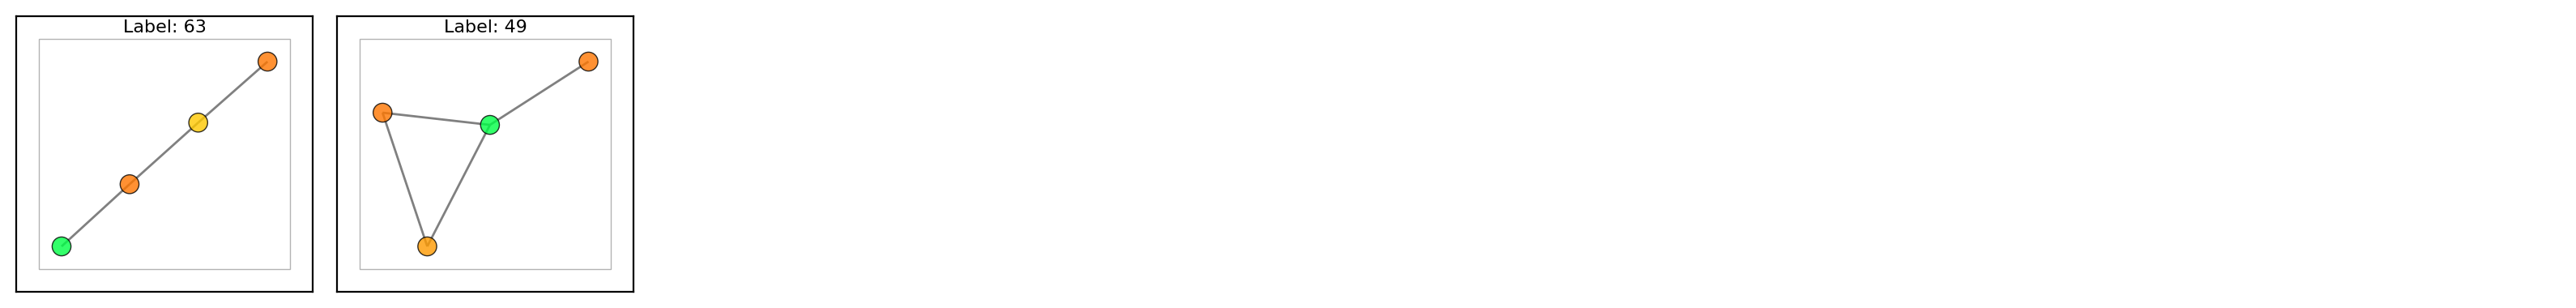

In [9]:
core_df = forward_compose(
    while_loop(
        function=split(),
        predicate=number_of_subgraph_nodes_greater_then(threshold=5),
        max_iterations=10,
    ),
    connected_component(),
)
while_loop_ag = draw(graph, core_df)


## Another `while_loop(...)` pattern

The original overview also showed a loop controlled by the number of interpretation nodes. The next pipeline keeps splitting while the current interpretation graph has fewer than five nodes.


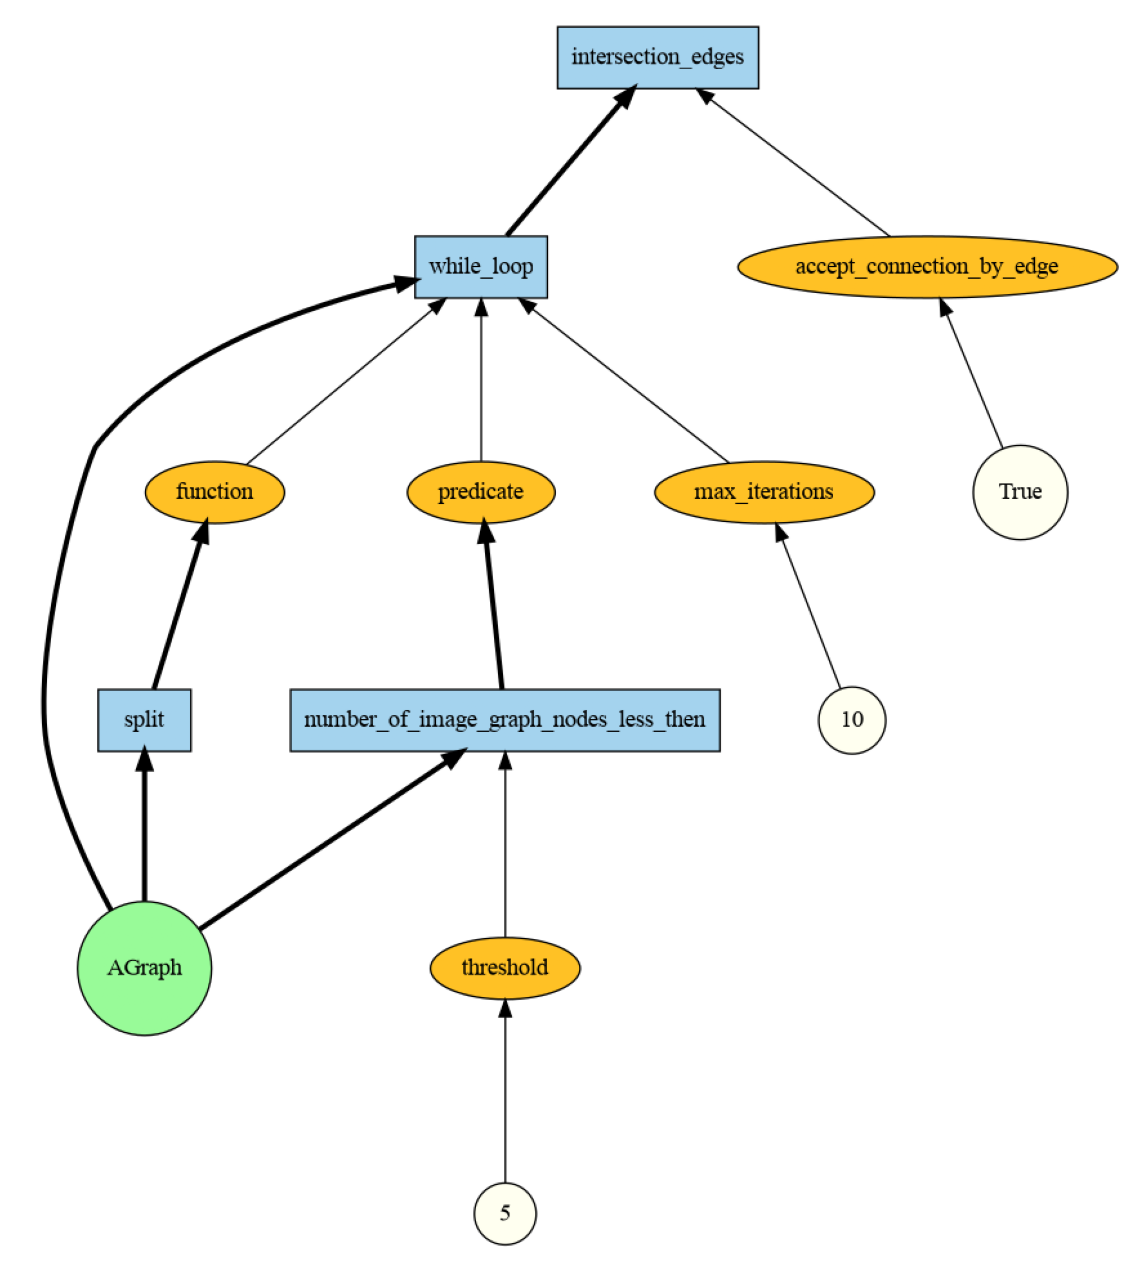

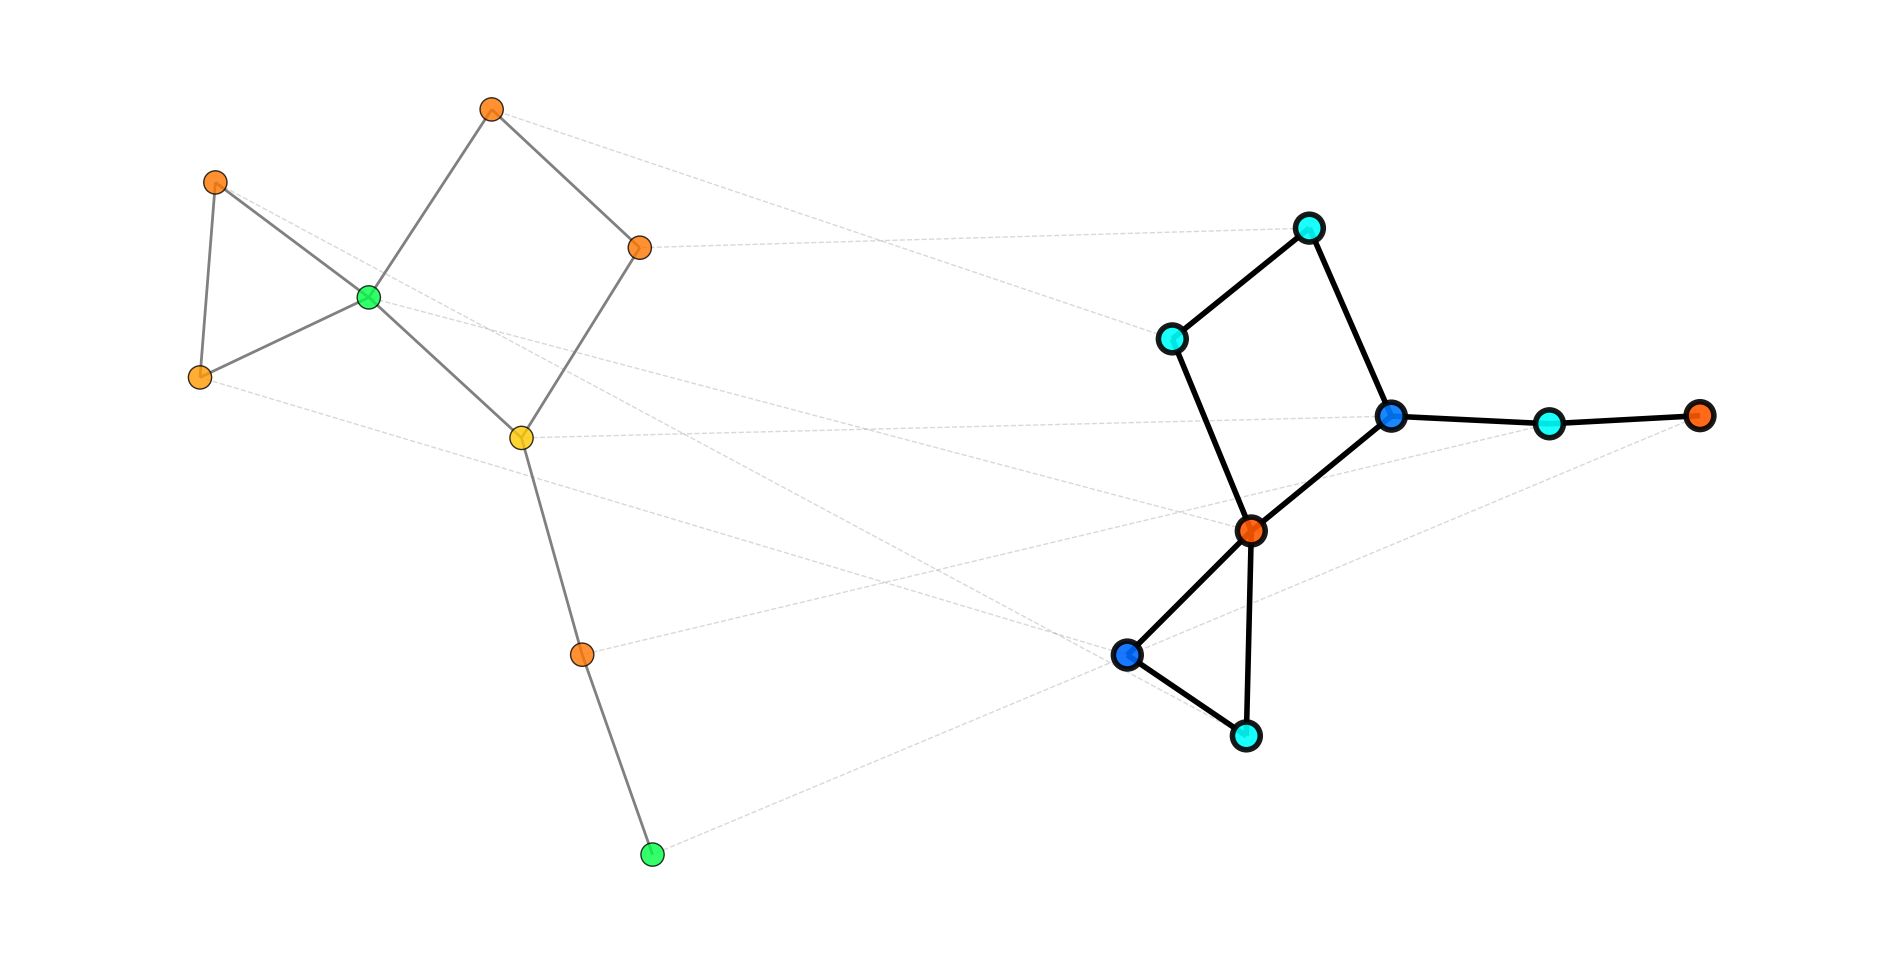

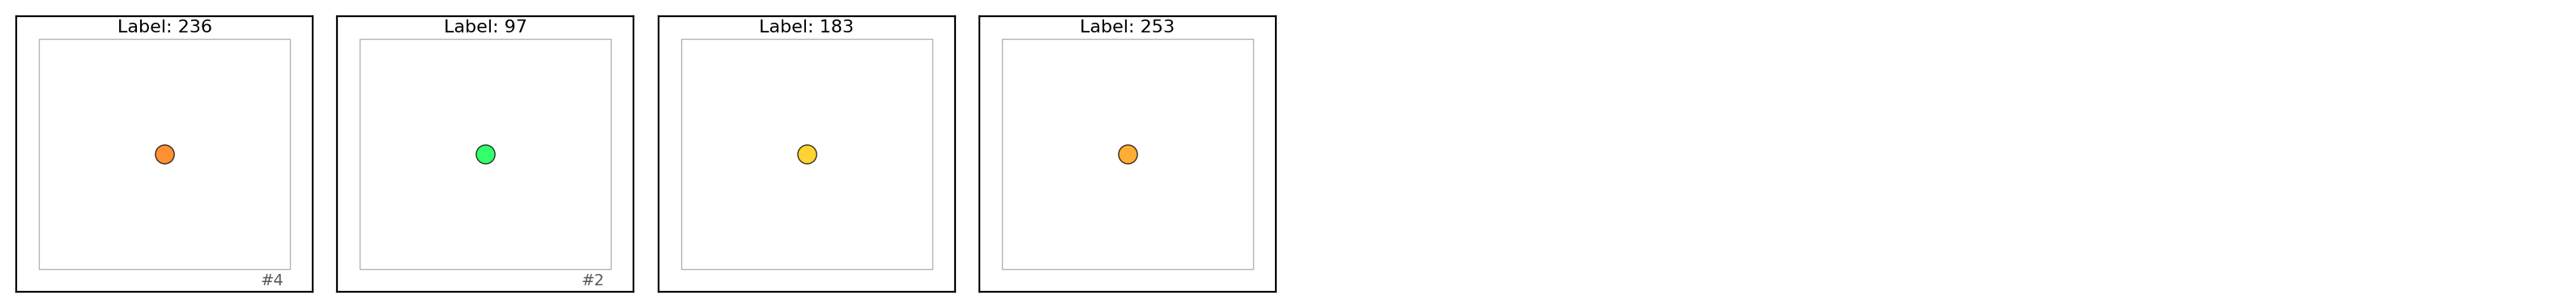

In [10]:
workflow = forward_compose(
    while_loop(
        function=split(),
        predicate=number_of_image_graph_nodes_less_then(threshold=5),
        max_iterations=10,
    ),
    intersection_edges(accept_connection_by_edge=True),
)
while_loop_size_ag = draw(graph, workflow)


## Inspect the decomposition graph itself

For control-flow operators it is often useful to inspect the operator DAG directly, not only the output graph.


nodes = 13 edges = 14


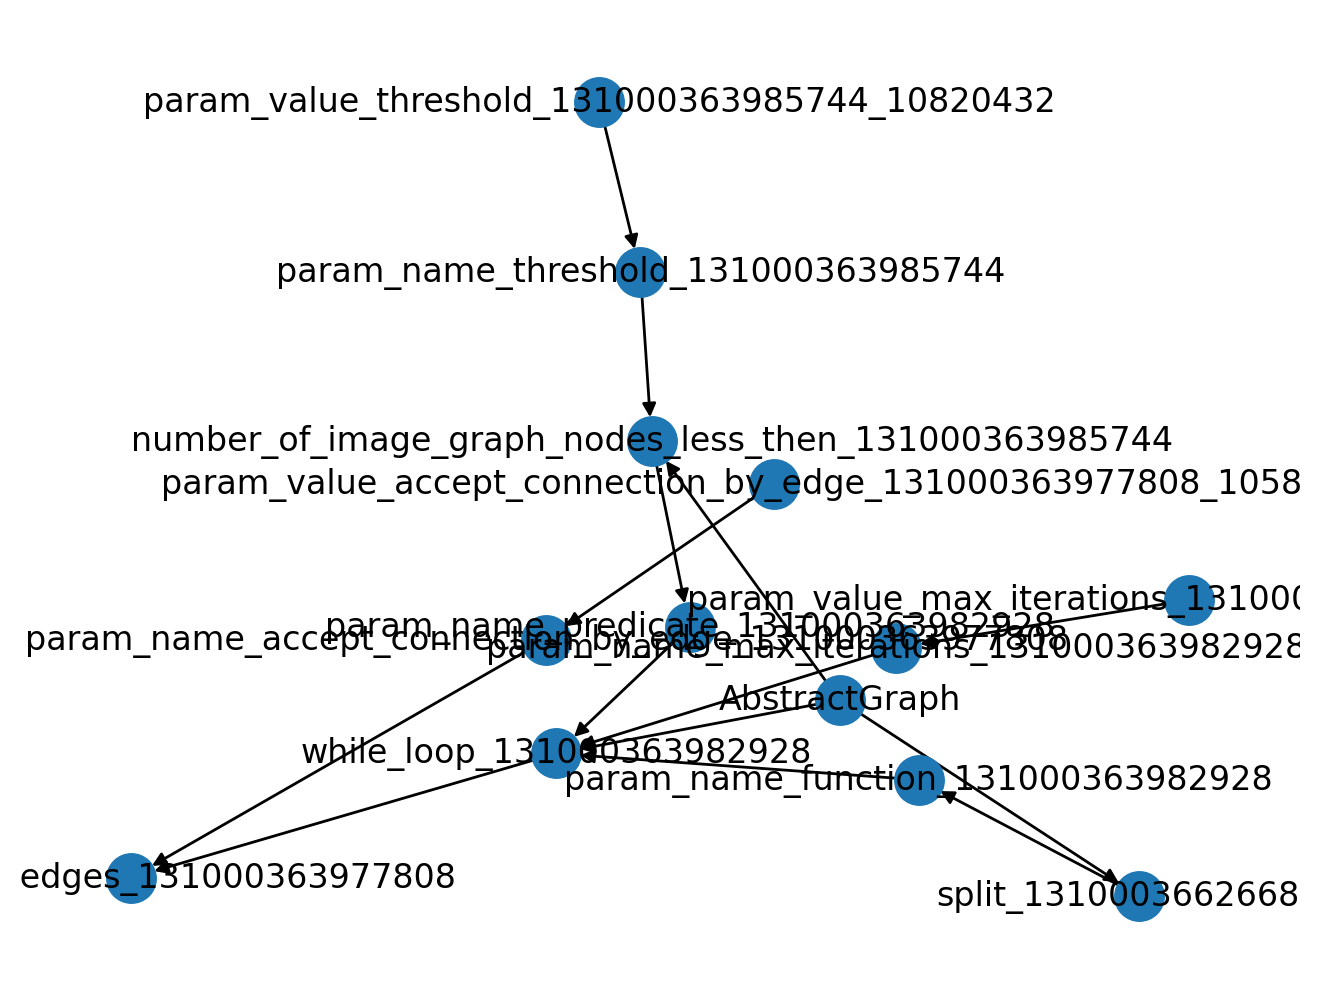

In [11]:
G = decomposition_to_graph(workflow)
print('nodes =', G.number_of_nodes(), 'edges =', G.number_of_edges())
nx.draw(G, with_labels=True)


## Practical reading

These operators let you treat an operator pipeline as a small graph program:

- `if_then_else(...)`: choose one branch based on current state
- `if_then_elif_else(...)`: choose among multiple ordered branches
- `for_loop(...)`: apply a transformation a fixed number of times
- `while_loop(...)`: iterate until a graph-level predicate says stop


## Summary

The control-flow operators are the point where `abstractgraph` pipelines stop looking like static chains and start looking like executable symbolic workflows. They are most useful when the right decomposition depth depends on the current graph state instead of being fixed in advance.

Previous: [05 Binary And Combination Operators](./example_abstract_graph_operators_05_binary_and_combination_operators.ipynb)  
Next: [07 XML And Operator Serialization](./example_abstract_graph_operators_07_xml_and_operator_serialization.ipynb)
